In [1]:
#imports and data upload
from sklearn.model_selection import StratifiedKFold#
from torch.utils.data import TensorDataset, DataLoader, Subset
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
X = np.load("usv_imgs.npy")
Y = np.load("usv_labels.npy")

In [2]:
#check to ensure labels and data are the same size
print(X.shape)
print(Y.shape)
print(X.dtype, Y.dtype)

#set image resolution
height = X.shape[1]
width = X.shape[2]

(3593, 64, 64, 3)
(3593,)
uint8 int64


In [3]:
#Code utilized from Zhuowen Tu's Cogs 181 UCSD
#This code tests wheteher a gpu is being utilized or if processing is being done via local cpu

# If there are GPUs, choose the first one for computing. Otherwise use CPU.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)  
# If 'cuda:0' is printed, it means GPU is available.

cpu


In [4]:
#preprossing image data for torch
# result of this block is a dataset prepped to be loaded into the dataloader for the cnn


#Convert the np label array data to a tensor of floats
Label_tensor =torch.from_numpy(Y)
#covert to ints for use with crossEntropyLoss
Label_tensor =Label_tensor.long()

#create a list of classes that will correspond to the labels tensor
#twentyfive = 0, noise=1
classes = ("twentyfive","noise")

#convert the image np array directly to a float tensor (expensive step)
Xt = torch.from_numpy(X)
#convert to float
Xt = Xt.float()

#normalize pixel values from 0-255 to 0-1 to stabalize gradients (expensive step)
Xt = Xt / 255.0

#change shape from  np (N, H, W, C) to (N, C, H, W) for PyTorch
Xt = Xt.permute(0, 3, 1, 2)

#combine the labels and data tensors into one iterable list
# that will be used in the pytorch dataloader
dataset = TensorDataset(Xt, Label_tensor)

In [5]:
# create object to split the data into train/validation sets by using stratified k-fold cross-validation object


#create variable to dictate batch size (how many images the model proceses at a time)
batch = 4
#create startified kfold xval splitter  - statified keeps category ratio the same as the data set
skf = StratifiedKFold(
    n_splits=5, # how many splits, or times the split-train-test process will run
    shuffle=True, # randomlly shuffle data prior to splitting
    random_state=42 # random seed
)

In [6]:
# helper function to plot confusion matrix
# takes in confusion matrix data and class labels
#returns confusion matrix visualization
def plot_confusion_matrix(cm, classes):
    #print grid
    plt.imshow(cm, interpolation='nearest') #no smoothing
    #set xaxis labels
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    #set y axis labels
    plt.yticks(tick_marks, classes)
    #for each class print value of the confusion matrix in the center
    for i in range(len(classes)):
        for j in range(len(classes)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [12]:
#Sanity check to check how data will be split
# Use skf object to Split the data into train/test set for all splits

#create lst for fold accuracies
fold_accuracies = []

#for each fold in the skf object, create var for train/test indx
for fold, (train_idx, val_idx) in enumerate(skf.split(Xt, Label_tensor)):
    print(f"\nFold {fold+1}/5") # print the current fold HARDCODED

    train_subset = Subset(dataset, train_idx) #create subset of training data
    val_subset = Subset(dataset, val_idx) # create subset for testing

    trainloader = DataLoader(train_subset, batch_size=batch, shuffle=True, num_workers=0) #load trainign data into shuffled batches
    testloader = DataLoader(val_subset, batch_size=batch, shuffle=False, num_workers=0) #load unshuffled test data

    print("Training samples:", len(train_subset))
    print("Validation samples:", len(val_subset))


Fold 1/5
Training samples: 2874
Validation samples: 719

Fold 2/5
Training samples: 2874
Validation samples: 719

Fold 3/5
Training samples: 2874
Validation samples: 719

Fold 4/5
Training samples: 2875
Validation samples: 718

Fold 5/5
Training samples: 2875
Validation samples: 718


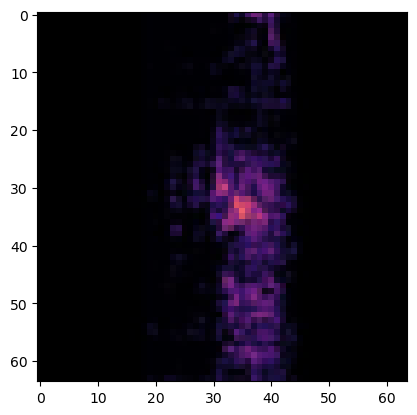

Label: twentyfive


In [13]:
#Sanity check: Ensure that the trainloader batch contains expected images and corresponding labels

#iterate through batches of images and corresponding labels in the training data (images)
for img,label in trainloader:
    #show image from dataloader, rearrange the order of the tensor in order to display correctly
    #from 3,h,w to h,w,3
    #only showing 1 img per batch (3rd)
    plt.imshow(img[2].permute(1,2,0).numpy())
    plt.show()
    
    #get the class of the current image
    category = classes[label[2].item()]
    print(f"Label: {category}")
    #break the for loop to only display one image for now, erasing break will print one image per batch
    break

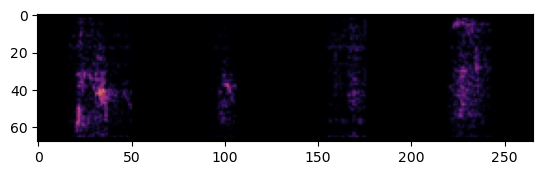

twentyfive noise noise twentyfive


In [27]:
# Sanity Check: Show an array of x=batchnumber images with their corresponding labels
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images.
dataiter = iter(trainloader)
images, labels = next(dataiter)
# Show images.
imshow(torchvision.utils.make_grid(images))
# Print labels.
print(' '.join('%5s' % classes[labels[j]] for j in range(batch)))

In [28]:
#Create CNN object
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        
        #convolution layer that takes in 3 channels and outputs 10
        #kernal size 3x3 padding of 1, output 10XheightXwidth (due to padding)
        self.Convolution1 = nn.Conv2d(3,10,3,padding=1)
        
        # max pooling layer, takes the maximum value in each 2x2 window, output = 10xheight/2xwidth/2
        self.Pool1 = nn.MaxPool2d(2)
        
        #convolution layer that takes in 10 channels and outputs 20
        #kernal size 3x3 padding of 1, output = height/2xwidth/2 (due to padding)
        self.Convolution2 = nn.Conv2d(10,20,3,padding = 1)
        
        #pooling layer, averages the imput in a 2x2 window, output = 20Xheight/4xwidth/4
        self.Pool3 = nn.AvgPool2d(2)

        #find appropriate number to flatten data to
        flatten_size = 20 * (height // 4) * (width // 4)

        
        #linear (fully connected layer) mapping 20Xheight/4xwidth/4 = x layers of input to 100 layers of output
        
        self.LinearLayer1= nn.Linear(flatten_size,100)
        
        #linear (fully connected layer) mapping 100 layers of input to 2 layers of output (possible categories)
        self.LinearLayer2 = nn.Linear(100,2)
        
        
        
        
        
        
    def forward(self, x): 
        #4x3xHeightxWidth
        
        #3x3 convo and Relu conversion (activation)
        x=F.leaky_relu(self.Convolution1(x))
        #4X10XHeightxWidth
        
        #2x2 max pooling
        x=self.Pool1(x)
        #4x10xHeight/2xWidth/2
        
        
        #3x3 convolution and Relu conversion
        x=F.leaky_relu(self.Convolution2(x))
        # 4x20xHeight/2xWidth/2
        
        #2x2 kernel average pooling
        x=self.Pool3(x)
        #4x20xHeight/4xWidth/4

       #flatten the output by using view method (equivalent to np reshape)
        #flatten each 20xHeight/4xWidth/4 into a vector of length 3xHeight/2xWidth/2 (using x.size to find batch size and -1 to infer 20Xheight/4xwidth/4
        x = x.view(x.size(0), -1)

        #fully connectedlayer, taking input of 20Xheight/4xwidth/4 from the flattend tensor and outputting to 100 neurons
        x=F.leaky_relu(self.LinearLayer1(x))
        
        ##fully connectedlayer, taking input of 100 from the flattend tensor and outputting to 2 neurons (categories)
        x = self.LinearLayer2(x)
        
        
        
        
        return x
# x= (score of class 1, score of class 2)
net = Net()     # Create the network instance.
net.to(device)  # Move the network parameters to the specified device.

Net(
  (Convolution1): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (Pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Convolution2): Conv2d(10, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (Pool3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (LinearLayer1): Linear(in_features=5120, out_features=100, bias=True)
  (LinearLayer2): Linear(in_features=100, out_features=2, bias=True)
)

In [29]:
# init empty lists for accuracies, confusion matrices, and misclassified images
fold_accuracies = []
all_confusion_matrices = []
all_misclassified_data = []

# set num of training iterations
epochs = 10

# Use skf object to Split the data into train/test set for all splits

# for each fold in the skf object, create var for train/test indx
for fold, (train_idx, val_idx) in enumerate(skf.split(Xt, Label_tensor)):
    
    print(f"\nFold {fold+1}/5") #print the current fold HARDCODED

    train_subset = Subset(dataset, train_idx) #create subset of training data
    val_subset = Subset(dataset, val_idx) #create subset of test data

    trainloader = DataLoader(train_subset, batch_size=batch, shuffle=True, num_workers=0) #load trainign data into shuffled batches
    testloader = DataLoader(val_subset, batch_size=batch, shuffle=False, num_workers=0) #load test data into unshuffled batch labels

    # disp len of training/test data
    print("Training samples:", len(train_subset))
    print("Validation samples:", len(val_subset))

    # reset Neural net ,loss function, and optimizer for current fold
    net = Net().to(device)
    loss_func = nn.CrossEntropyLoss()
    opt = optim.AdamW(net.parameters(), lr=0.001)

    # init list to store current loss
    avg_losses = []
    # print average loss for every x batch
    print_freq = 100

    # TRAINING mode
    net.train()
    # for every epoch (iteration throught the data set)
    for epoch in range(epochs):
        #reset loss
        running_loss = 0.0
        # for each batch in the training data
        for i, data in enumerate(trainloader, 0):
            # separate image and label
            inputs, labels = data
            # load inputs and labels
            inputs, labels = inputs.to(device), labels.to(device)

            #reset the gradient from previous batch
            opt.zero_grad()
            #predict using current net
            outputs = net(inputs)
            # calculate accuracy
            loss = loss_func(outputs, labels)
            #compute weight change direction
            loss.backward()
            #update weights
            opt.step()

            #update loss
            running_loss += loss.item()
            #if on preallocated batch freq for printing
            if (i + 1) % print_freq == 0:
                # store loss
                avg_losses.append(running_loss / print_freq)
                # print current av loss
                print(f"Fold {fold+1}, Epoch {epoch+1}, Batch {i+1}, Loss: {running_loss / print_freq:.4f}")
                #reset loss
                running_loss = 0.0

    # VALIDATION MODE
    net.eval()
    # init variables for accuracy counting
    correct = 0
    total = 0
    # init lists for predicted and true labels
    all_preds = []
    all_labels = []
    #init lists for misclassified data
    misclassified_images = []
    misclassified_true = []
    misclassified_pred = []

    #disable gradient for testing
    with torch.no_grad():
        # for all the test data
        for data in testloader:
            # separate image and label
            images, labels = data
            #load inputs and labels
            inputs, labels = inputs.to(device), labels.to(device)
            
            #predict using current net
            outputs = net(images)
            # classify current image based on max logit score
            _, predicted = torch.max(outputs, 1)

            # store total num of predications
            total += labels.size(0)
            # store correct predictions in this batch
            correct += (predicted == labels).sum().item()

            #store current batch predictions and labels as np array for later use
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # store incorrectly classified images
            #find incorrect prediction from current batch
            wrong_mask = predicted != labels
            #store the incorrect image, prediction, and label from the current batch
            misclassified_images.extend(images[wrong_mask].cpu())
            misclassified_true.extend(labels[wrong_mask].cpu().numpy())
            misclassified_pred.extend(predicted[wrong_mask].cpu().numpy())

    # calulate accuracy for this fold
    fold_acc = 100 * correct / total
    # store this accuracy
    fold_accuracies.append(fold_acc)
    #print the accuracy
    print(f"Fold {fold+1} Accuracy: {fold_acc:.2f}%")

    # compute and store total confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    all_confusion_matrices.append(cm)

    # store total misclassified data for this fold
    all_misclassified_data.append({
        "images": misclassified_images,
        "true": misclassified_true,
        "pred": misclassified_pred
    })
#print all fold accuracies and mean of those accuracies
print("\nCross-validation complete.")
print("Fold accuracies:", fold_accuracies)
print("Mean accuracy: %.2f%%" % (sum(fold_accuracies) / len(fold_accuracies)))


Fold 1/5
Training samples: 2874
Validation samples: 719
Fold 1, Epoch 1, Batch 100, Loss: 0.5199
Fold 1, Epoch 1, Batch 200, Loss: 0.3792
Fold 1, Epoch 1, Batch 300, Loss: 0.2868
Fold 1, Epoch 1, Batch 400, Loss: 0.2414
Fold 1, Epoch 1, Batch 500, Loss: 0.2702
Fold 1, Epoch 1, Batch 600, Loss: 0.2896
Fold 1, Epoch 1, Batch 700, Loss: 0.2422
Fold 1, Epoch 2, Batch 100, Loss: 0.2456
Fold 1, Epoch 2, Batch 200, Loss: 0.2680
Fold 1, Epoch 2, Batch 300, Loss: 0.2333
Fold 1, Epoch 2, Batch 400, Loss: 0.2000
Fold 1, Epoch 2, Batch 500, Loss: 0.2034
Fold 1, Epoch 2, Batch 600, Loss: 0.2389
Fold 1, Epoch 2, Batch 700, Loss: 0.2182
Fold 1, Epoch 3, Batch 100, Loss: 0.1978
Fold 1, Epoch 3, Batch 200, Loss: 0.2021
Fold 1, Epoch 3, Batch 300, Loss: 0.1906
Fold 1, Epoch 3, Batch 400, Loss: 0.1834
Fold 1, Epoch 3, Batch 500, Loss: 0.2127
Fold 1, Epoch 3, Batch 600, Loss: 0.1780
Fold 1, Epoch 3, Batch 700, Loss: 0.2238
Fold 1, Epoch 4, Batch 100, Loss: 0.1818
Fold 1, Epoch 4, Batch 200, Loss: 0.1866



Fold 1


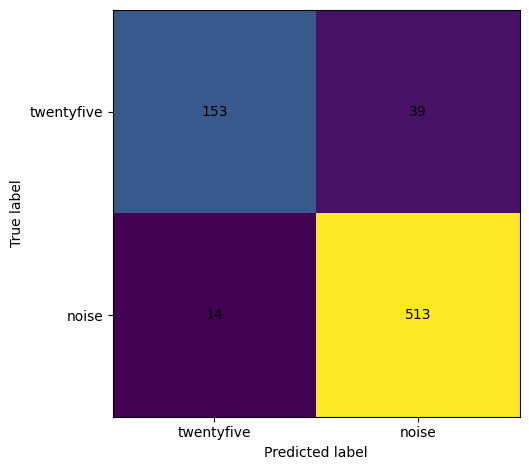


Fold 2


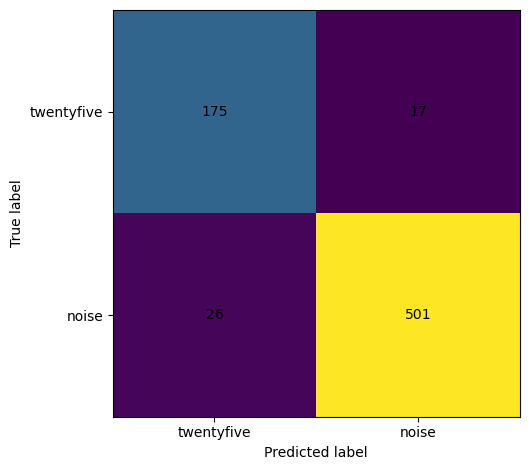


Fold 3


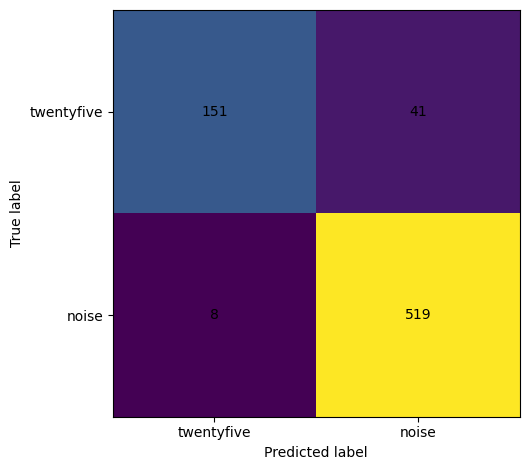


Fold 4


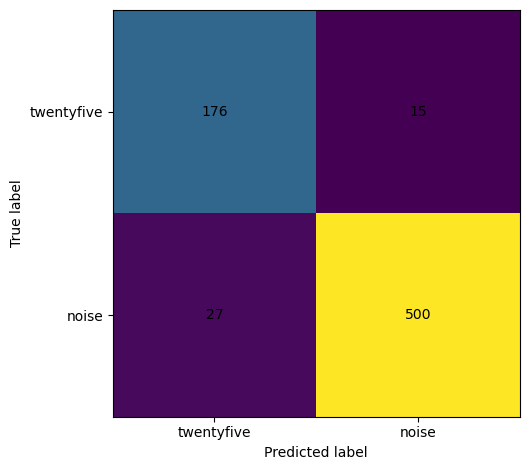


Fold 5


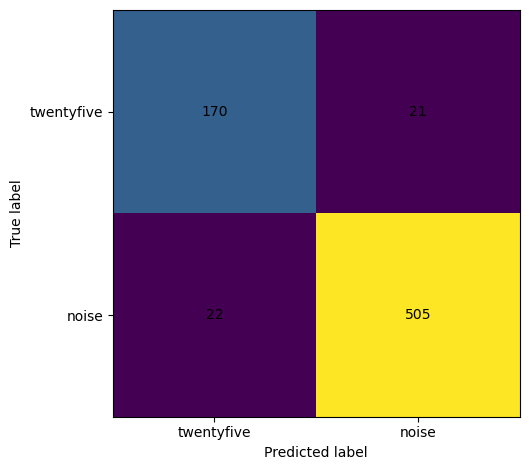

In [30]:
#Where did We go wrong?

for i, cm in enumerate(all_confusion_matrices):
    print(f"\nFold {i+1}")
    plot_confusion_matrix(cm, classes)

Number of misclassified images in fold 2: 43


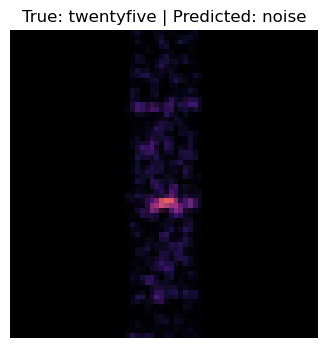

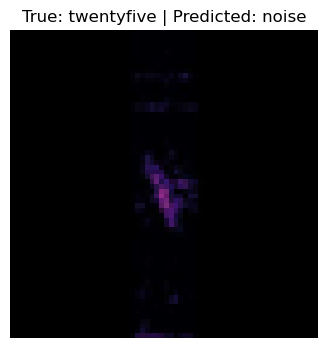

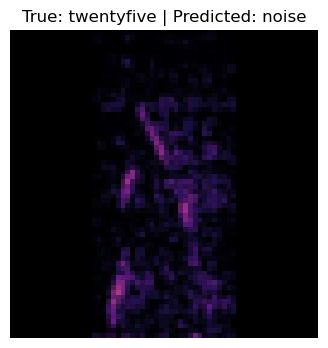

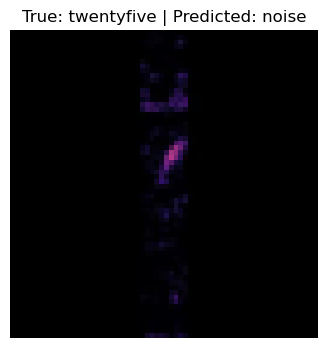

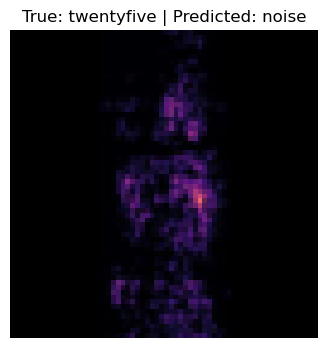

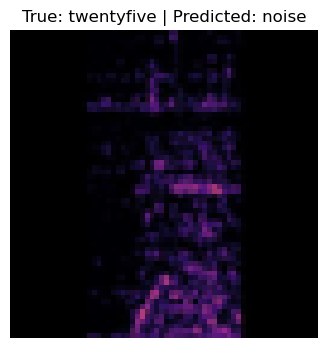

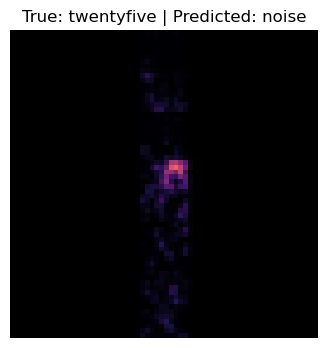

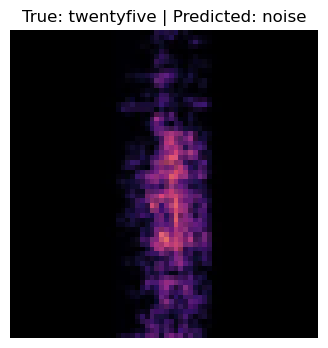

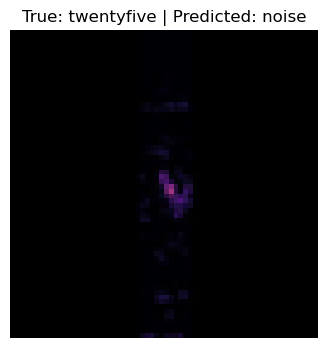

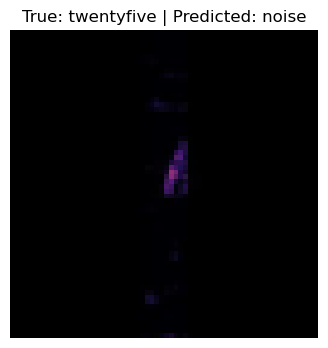

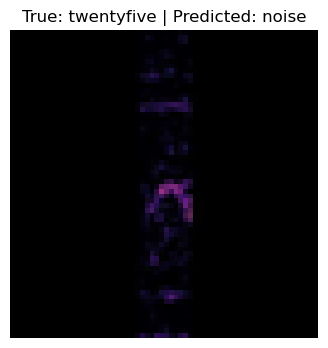

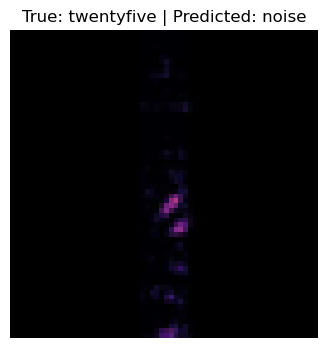

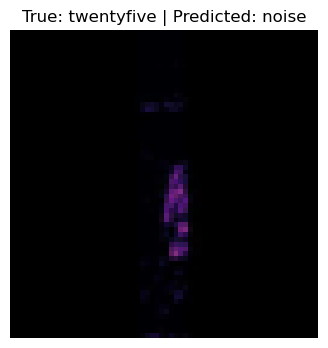

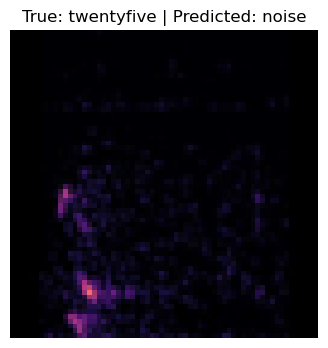

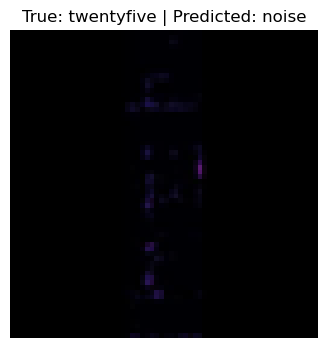

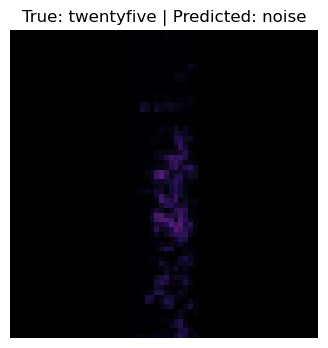

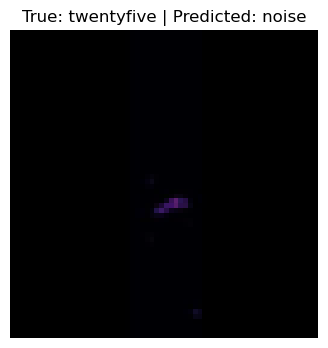

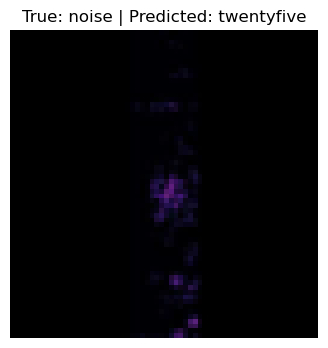

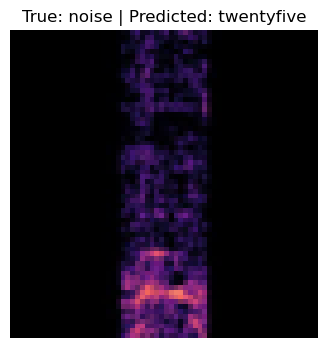

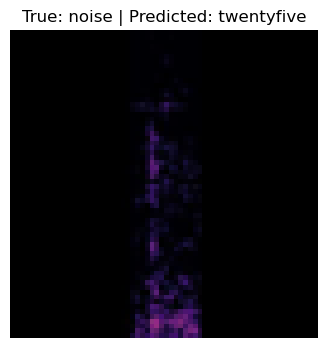

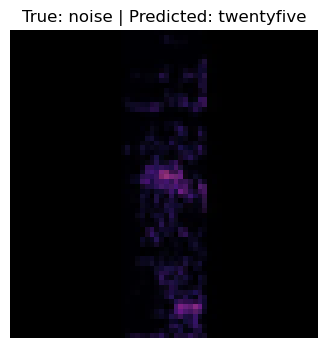

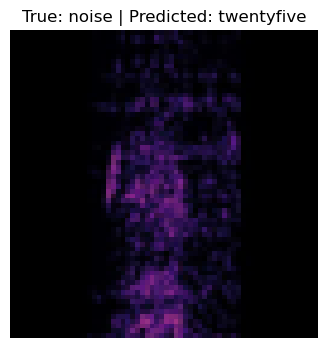

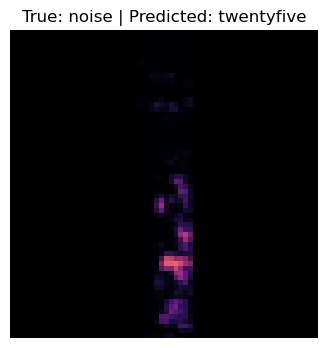

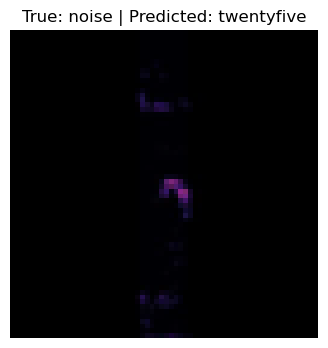

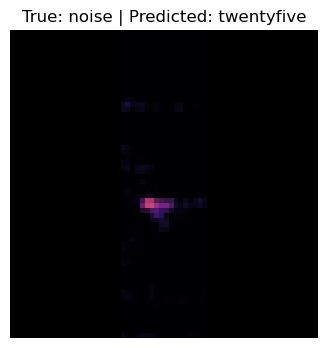

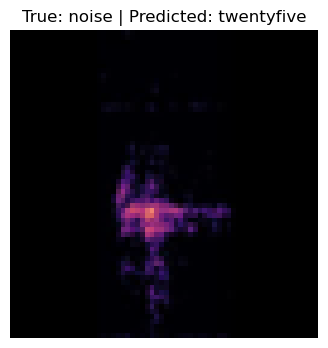

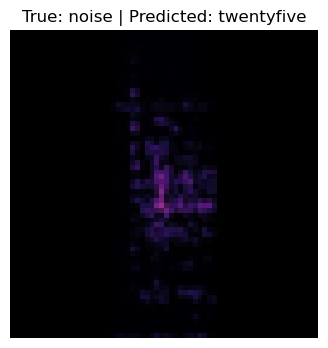

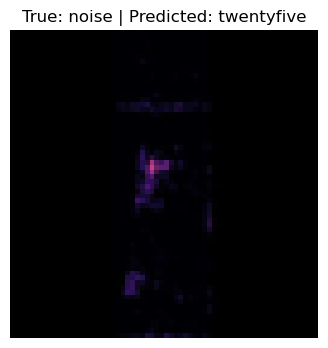

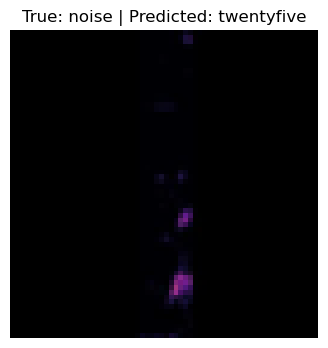

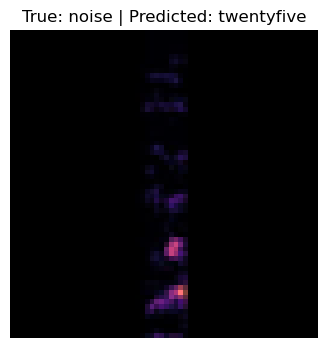

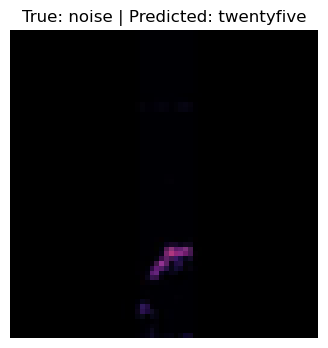

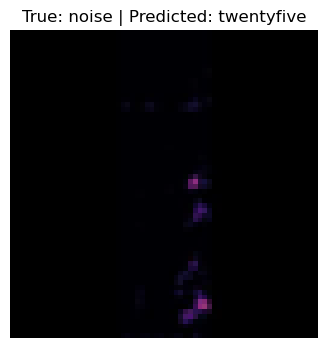

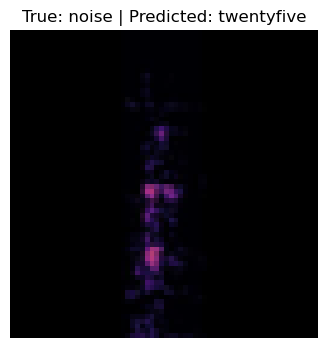

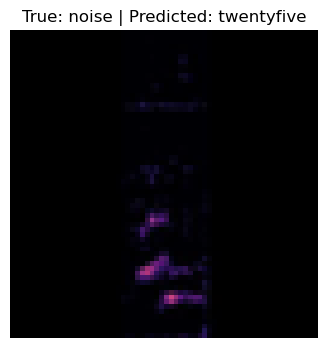

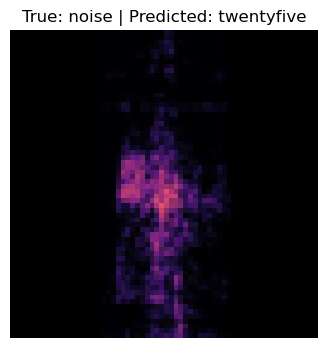

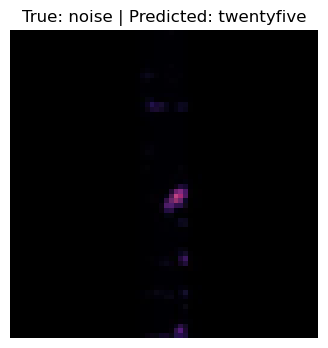

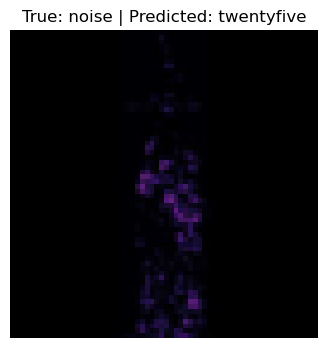

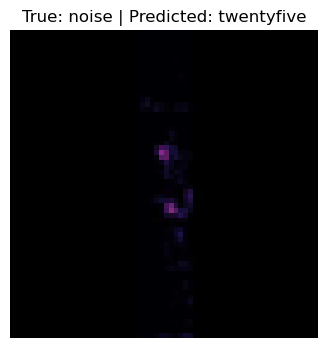

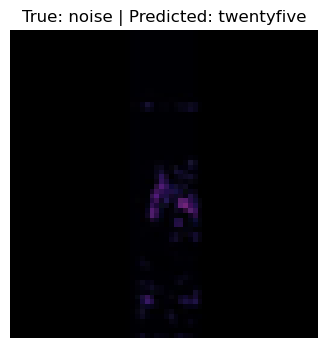

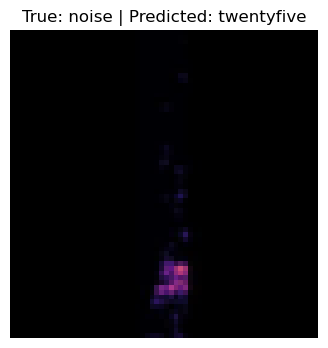

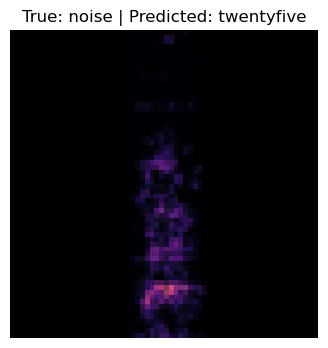

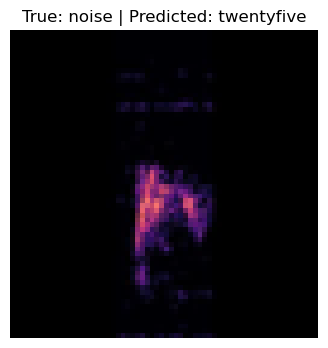

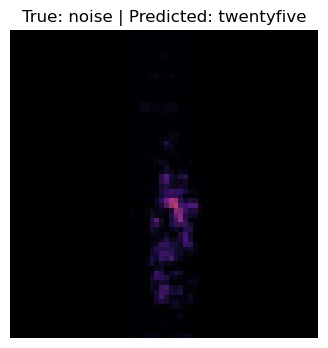

In [33]:
fold_num = 2


data = all_misclassified_data[fold_num-1]

images = data["images"]
true = data["true"]
pred = data["pred"]

print(f"Number of misclassified images in fold {fold_num}: {len(images)}")

for i in range(len(images)):
    img = images[i].permute(1, 2, 0).numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"True: {classes[true[i]]} | Predicted: {classes[pred[i]]}")
    plt.axis("off")
    plt.show()